<a href="https://colab.research.google.com/github/lfmuneramm/Aprendizaje_No_Supervisado/blob/main/RETO3_LFMM_IDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Descripción del caso**
<br/>

Una compañía internacional de e-commerce cuenta con seis bloques físicos de distribución de productos (A, B, C, D, E, F). Debido a restricciones presupuestales, la empresa debe reducir su infraestructura y consolidar los bloques en tres bloques principales (A, B, C). Para llevar a cabo este proceso, se plantea la utilización de un proceso de integración de datos multidimensional que permita reorganizar la información de manera objetiva y fundamentada en el análisis estadístico.

El procedimiento comienza con la caracterización inicial de los bloques de referencia (A, B, C). En esta etapa se analizan las variables disponibles, diferenciando entre cuantitativas y cualitativas, y se calculan medidas estadísticas como la media, desviación estándar, asimetría y curtosis. Esto permitirá tener una visión general de las características de los bloques antes de realizar la integración.

Posteriormente, se realiza un proceso de clusterización sobre los bloques que se van a integrar (D, E, F), empleando el método K-Medoids. Este procedimiento permite identificar valores representativos y asignar a cada dato un valor de pertenencia respecto a los bloques de referencia.

La integración se llevará a cabo asignando los datos de los bloques C, D, E y F al bloque de referencia (A, B o C) con el cual obtengan el máximo valor de pertenencia. De esta forma, se asegura que la redistribución de los datos respete las similitudes y patrones detectados por el modelo.

Finalmente, se repite el análisis estadístico de caracterización en los bloques resultantes (A, B, C) tras la integración. Esta segunda caracterización permitirá comparar los resultados y evaluar los cambios en las variables después del proceso de consolidación, ofreciendo una visión clara de cómo los bloques se reorganizan y representan a los datos integrados.

&nbsp;

ID → Identificador único de cada pedido.

Warehouse_block → Bloque o sección del almacén de donde sale el producto.

Mode_of_Shipment → Medio de transporte usado (avión, barco, carretera).

Customer_care_calls → Número de llamadas del cliente a servicio al cliente.

Customer_rating → Calificación del cliente al servicio (escala 1–5).

Cost_of_the_Product → Precio del producto comprado (sin descuento).

Prior_purchases → Número de compras previas del cliente.

Product_importance → Nivel de importancia del producto (bajo, medio, alto).

Gender → Género del cliente (masculino/femenino).

Discount_offered → Descuento aplicado al producto.

Weight_in_gms → Peso del producto en gramos.

Reached.on.Time_Y.N → Indicador si llegó a tiempo (0 = sí, 1 = no).

0. Importamos las librerias

In [ ]:
#importar las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import warnings

1. Cargamos la base de datos

In [ ]:
nxl='/content/Train.csv'
XDB=pd.read_csv(nxl)
XDB.head()


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


2. Exploramos los datos

In [ ]:
#Usamos el DataFrame ya cargado
df = XDB.copy()  # Trabajamos con una copia para no modificar el original

#Hacemos una exploración de los datos

print(f"Dimensiones del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"\nPrimeras 5 filas:")
print(df.head())

print(f"\nInformación general del dataset:")
print(df.info())

print(f"\nDistribución de bloques:")
print(df['Warehouse_block'].value_counts().sort_index())

Dimensiones del dataset: (10999, 12)
Columnas: ['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']

Primeras 5 filas:
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183  

3. Identificamos las variables

In [ ]:
#Variables numéricas (cuantitativas)
numerical_vars = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
                  'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

# Variables categóricas (cualitativas)
categorical_vars = ['Mode_of_Shipment', 'Product_importance', 'Gender', 'Reached.on.Time_Y.N']

print(f"Variables numéricas (cuantitativas): {numerical_vars}")
print(f"Variables categóricas (cualitativas): {categorical_vars}")

# Verificar valores faltantes
print(f"\nValores faltantes por variable:")
print(df.isnull().sum())

Variables numéricas (cuantitativas): ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']
Variables categóricas (cualitativas): ['Mode_of_Shipment', 'Product_importance', 'Gender', 'Reached.on.Time_Y.N']

Valores faltantes por variable:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


4. Hacemos una función para la caracterización

In [ ]:
def caracterizar_variables(data, titulo, vars_numericas, vars_categoricas):
    """
    Realiza caracterización estadística de variables numéricas y categóricas
    """
    print(f"\n{titulo}")
    print("=" * len(titulo))

    # Caracterización de variables numéricas
    print("\nVARIABLES NUMÉRICAS (CUANTITATIVAS):")
    print("-" * 40)

    stats_df = pd.DataFrame()
    for var in vars_numericas:
        if var in data.columns:
            serie = data[var]
            stats = {
                'Variable': var,
                'Media': serie.mean(),
                'Desviación Estándar': serie.std(),
                'Asimetría': serie.skew(),
                'Curtosis': serie.kurtosis(),
                'Mínimo': serie.min(),
                'Máximo': serie.max(),
                'Mediana': serie.median()
            }
            stats_df = pd.concat([stats_df, pd.DataFrame([stats])], ignore_index=True)

    print(stats_df.round(4).to_string(index=False))

    # Caracterización de variables categóricas
    print(f"\n\nVARIABLES CATEGÓRICAS (CUALITATIVAS):")
    print("-" * 40)

    for var in vars_categoricas:
        if var in data.columns:
            print(f"\n{var}:")
            conteos = data[var].value_counts()
            porcentajes = data[var].value_counts(normalize=True) * 100

            for categoria in conteos.index:
                print(f"  {categoria}: {conteos[categoria]} ({porcentajes[categoria]:.1f}%)")

    return stats_df


5. Caracterización antes de la integración

In [ ]:
# Filtrar datos por bloques de referencia (A, B, C)
bloques_referencia = ['A', 'B', 'C']
datos_referencia = df[df['Warehouse_block'].isin(bloques_referencia)].copy()

print(f"Datos en bloques de referencia (A,B,C): {len(datos_referencia)} registros")

# Caracterización por bloque ANTES de la integración
for bloque in bloques_referencia:
    datos_bloque = datos_referencia[datos_referencia['Warehouse_block'] == bloque]
    titulo = f"BLOQUE {bloque} - ANTES DE LA INTEGRACIÓN ({len(datos_bloque)} registros)"
    caracterizar_variables(datos_bloque, titulo, numerical_vars, categorical_vars)

Datos en bloques de referencia (A,B,C): 5499 registros

BLOQUE A - ANTES DE LA INTEGRACIÓN (1833 registros)

VARIABLES NUMÉRICAS (CUANTITATIVAS):
----------------------------------------
           Variable     Media  Desviación Estándar  Asimetría  Curtosis  Mínimo  Máximo  Mediana
Customer_care_calls    4.0382               1.1387     0.4115   -0.3182       2       7      4.0
    Customer_rating    2.9574               1.4347     0.0458   -1.3348       1       5      3.0
Cost_of_the_Product  208.7676              48.6230    -0.1334   -0.9990      96     310    212.0
    Prior_purchases    3.5777               1.5154     1.6593    3.9013       2      10      3.0
   Discount_offered   13.2226              16.2141     1.8527    2.1918       1      65      7.0
      Weight_in_gms 3615.4490            1646.4195    -0.2295   -1.4877    1004    6000   4127.0


VARIABLES CATEGÓRICAS (CUALITATIVAS):
----------------------------------------

Mode_of_Shipment:
  Ship: 1242 (67.8%)
  Flight: 297

6. Preparamos los datos para el clustering

In [ ]:
# Datos a integrar (bloques D, E, F)
bloques_integracion = ['D', 'E', 'F']
datos_integracion = df[df['Warehouse_block'].isin(bloques_integracion)].copy()

print(f"Datos para integrar (D,E,F): {len(datos_integracion)} registros")
print(f"Distribución por bloque:")
print(datos_integracion['Warehouse_block'].value_counts().sort_index())

# Preparar matriz de características numéricas para clustering
X_referencia = datos_referencia[numerical_vars].copy()
X_integracion = datos_integracion[numerical_vars].copy()

# Verificar y tratar valores faltantes
print(f"\nValores faltantes en datos de referencia: {X_referencia.isnull().sum().sum()}")
print(f"Valores faltantes en datos de integración: {X_integracion.isnull().sum().sum()}")

# Rellenar valores faltantes con la mediana (más robusto que la media)
X_referencia = X_referencia.fillna(X_referencia.median())
X_integracion = X_integracion.fillna(X_integracion.median())

Datos para integrar (D,E,F): 5500 registros
Distribución por bloque:
Warehouse_block
D    1834
F    3666
Name: count, dtype: int64

Valores faltantes en datos de referencia: 0
Valores faltantes en datos de integración: 0


7. Normalizamos los datos para mejorar su calidad

In [ ]:
# Normalizar datos usando StandardScaler
scaler = StandardScaler()
X_referencia_scaled = scaler.fit_transform(X_referencia)
X_integracion_scaled = scaler.transform(X_integracion)

print("Datos normalizados usando StandardScaler")
print("- Media ≈ 0, Desviación estándar ≈ 1")

Datos normalizados usando StandardScaler
- Media ≈ 0, Desviación estándar ≈ 1


8. Aplicamos clustering con K-MEDOIDS

In [ ]:
# Aplicar K-Medoids con k=3 (para los 3 bloques de referencia A,B,C)
print("Aplicando K-Medoids con k=3...")

kmedoids = KMedoids(n_clusters=3, random_state=42, method='pam', metric='euclidean')
clusters_referencia = kmedoids.fit_predict(X_referencia_scaled)

# Evaluar calidad del clustering
silhouette_avg = silhouette_score(X_referencia_scaled, clusters_referencia)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Asignar clusters a los datos de referencia
datos_referencia['Cluster'] = clusters_referencia

# Mostrar distribución de clusters por bloque original
print(f"\nDistribución de clusters en bloques de referencia:")
cluster_distribution = pd.crosstab(datos_referencia['Warehouse_block'],
                                   datos_referencia['Cluster'],
                                   margins=True)
print(cluster_distribution)

Aplicando K-Medoids con k=3...
Silhouette Score: 0.2802

Distribución de clusters en bloques de referencia:
Cluster             0    1     2   All
Warehouse_block                       
A                1074  308   451  1833
B                1070  325   438  1833
C                1076  332   425  1833
All              3220  965  1314  5499


Vemos que el coeficiente de la silueta, es bueno, pues un buen coeficiente oscila entre 0,25 a 0,5

9. Asignamos los datos de integración

In [ ]:
# Obtener los medoides (centros de clusters) de los bloques de referencia A,B,C
medoids_indices = kmedoids.medoid_indices_
XC = X_referencia_scaled[medoids_indices]  # Matriz de medoides (3 x n_features)

print(f"Medoides obtenidos para los 3 bloques de referencia:")
print(f"Forma de XC (medoides): {XC.shape}")

# XD será nuestra matriz de datos a integrar
XD = X_integracion_scaled  # Datos de bloques D,E,F normalizados
print(f"Forma de XD (datos a integrar): {XD.shape}")

# Calcular valores de pertenencia usando la fórmula específica
print(f"\nCalculando valores de pertenencia con fórmula: VP = exp(-0.5 * mean(((XC - XD[k,]) / XC)²))")

# Matriz para almacenar valores de pertenencia (n_datos_integracion x 3_bloques)
valores_pertenencia = np.zeros((len(XD), 3))

# Para cada dato a integrar (k)
for k in range(len(XD)):
    XD_k = XD[k, :]  # Dato k a integrar

    # Para cada bloque de referencia (medoide)
    for i in range(3):  # 3 bloques A, B, C
        XC_i = XC[i, :]  # Medoide del bloque i

        # Evitar división por cero añadiendo epsilon pequeño
        epsilon = 1e-10
        XC_safe = XC_i + epsilon

        # Calcular VP usando la fórmula específica
        # VP = exp(-0.5 * mean(((XC - XD[k,]) / XC)²))
        diferencia_relativa = (XC_safe - XD_k) / XC_safe
        diferencia_cuadrada = diferencia_relativa ** 2
        media_diferencias = np.mean(diferencia_cuadrada)

        VP = np.exp(-0.5 * media_diferencias)
        valores_pertenencia[k, i] = VP

    # Mostrar progreso cada 500 registros
    if (k + 1) % 500 == 0 or k == 0:
        print(f"Procesado {k + 1}/{len(XD)} registros...")


print(f"Forma de matriz de pertenencia: {valores_pertenencia.shape}")

# Mostrar estadísticas de los valores de pertenencia
print(f"\nEstadísticas de valores de pertenencia:")
print(f"- Mínimo: {np.min(valores_pertenencia):.6f}")
print(f"- Máximo: {np.max(valores_pertenencia):.6f}")
print(f"- Media: {np.mean(valores_pertenencia):.6f}")
print(f"- Desviación estándar: {np.std(valores_pertenencia):.6f}")

# Asignar cada dato al bloque con MÁXIMO valor de pertenencia
cluster_asignado_pertenencia = np.argmax(valores_pertenencia, axis=1)
valores_max_pertenencia = np.max(valores_pertenencia, axis=1)

# Agregar información de pertenencia a los datos de integración
datos_integracion['VP_Bloque_A'] = valores_pertenencia[:, 0]
datos_integracion['VP_Bloque_B'] = valores_pertenencia[:, 1]
datos_integracion['VP_Bloque_C'] = valores_pertenencia[:, 2]
datos_integracion['Cluster_Asignado'] = cluster_asignado_pertenencia
datos_integracion['VP_Maximo'] = valores_max_pertenencia

# Mapear clusters a bloques (0->A, 1->B, 2->C)
mapeo_cluster_bloque = {0: 'A', 1: 'B', 2: 'C'}

# Asignar nuevo bloque basado en máximo valor de pertenencia
datos_integracion['Nuevo_Bloque'] = datos_integracion['Cluster_Asignado'].map(mapeo_cluster_bloque)

print(f"\nAsignación basada en MÁXIMO VALOR DE PERTENENCIA:")
print("-" * 50)

# Mostrar distribución de asignaciones
asignacion_summary = datos_integracion.groupby(['Warehouse_block', 'Nuevo_Bloque']).size().unstack(fill_value=0)
print("Matriz de reasignación (Bloque Original → Nuevo Bloque):")
print(asignacion_summary)

# Mostrar estadísticas de valores de pertenencia máximos
print(f"\nEstadísticas de valores de pertenencia MÁXIMOS:")
print(f"- Pertenencia máxima promedio: {np.mean(valores_max_pertenencia):.6f}")
print(f"- Pertenencia máxima mínima: {np.min(valores_max_pertenencia):.6f}")
print(f"- Pertenencia máxima máxima: {np.max(valores_max_pertenencia):.6f}")

# Mostrar ejemplos de asignaciones con sus valores de pertenencia
print(f"\nEjemplos de asignaciones (primeros 10 registros):")
print("-" * 60)
ejemplos = datos_integracion[['Warehouse_block', 'Nuevo_Bloque', 'VP_Bloque_A',
                             'VP_Bloque_B', 'VP_Bloque_C', 'VP_Maximo']].head(10)
print(ejemplos.round(6).to_string(index=False))

# Análisis de calidad de las asignaciones
print(f"\nANÁLISIS DE CALIDAD DE ASIGNACIONES:")
print("-" * 40)

# Contar asignaciones por bloque nuevo
conteos_nuevos = datos_integracion['Nuevo_Bloque'].value_counts().sort_index()
print(f"Distribución en nuevos bloques:")
for bloque, count in conteos_nuevos.items():
    porcentaje = (count / len(datos_integracion)) * 100
    print(f"  Bloque {bloque}: {count} registros ({porcentaje:.1f}%)")

# Análizar confianza de asignaciones (valores de pertenencia altos indican mayor confianza)
umbral_confianza = 0.6  # Umbral para considerar asignación confiable
asignaciones_confiables = np.sum(valores_max_pertenencia > umbral_confianza)
porcentaje_confiable = (asignaciones_confiables / len(valores_max_pertenencia)) * 100

print(f"\nConfianza de asignaciones (VP > {umbral_confianza}):")
print(f"  Asignaciones confiables: {asignaciones_confiables}/{len(valores_max_pertenencia)} ({porcentaje_confiable:.1f}%)")

# Mostrar distribución de valores de pertenencia por bloque asignado
print(f"\nValores de pertenencia promedio por bloque asignado:")
for i, bloque in enumerate(['A', 'B', 'C']):
    mask = datos_integracion['Nuevo_Bloque'] == bloque
    if np.sum(mask) > 0:
        vp_promedio = np.mean(datos_integracion.loc[mask, 'VP_Maximo'])
        print(f"  Bloque {bloque}: VP promedio = {vp_promedio:.6f}")



Medoides obtenidos para los 3 bloques de referencia:
Forma de XC (medoides): (3, 6)
Forma de XD (datos a integrar): (5500, 6)

Calculando valores de pertenencia con fórmula: VP = exp(-0.5 * mean(((XC - XD[k,]) / XC)²))
Procesado 1/5500 registros...
Procesado 500/5500 registros...
Procesado 1000/5500 registros...
Procesado 1500/5500 registros...
Procesado 2000/5500 registros...
Procesado 2500/5500 registros...
Procesado 3000/5500 registros...
Procesado 3500/5500 registros...
Procesado 4000/5500 registros...
Procesado 4500/5500 registros...
Procesado 5000/5500 registros...
Procesado 5500/5500 registros...
Forma de matriz de pertenencia: (5500, 3)

Estadísticas de valores de pertenencia:
- Mínimo: 0.000000
- Máximo: 0.988811
- Media: 0.042370
- Desviación estándar: 0.151680

Asignación basada en MÁXIMO VALOR DE PERTENENCIA:
--------------------------------------------------
Matriz de reasignación (Bloque Original → Nuevo Bloque):
Nuevo_Bloque       A    B     C
Warehouse_block            

10. Realizamos la Integración final de los datos

In [ ]:
# Crear dataset integrado
datos_integrados = pd.concat([
    datos_referencia[datos_referencia.columns[:-1]],  # Excluir columna 'Cluster'
    datos_integracion.assign(Warehouse_block=datos_integracion['Nuevo_Bloque'])[datos_referencia.columns[:-1]]
], ignore_index=True)

print(f"Dataset integrado: {len(datos_integrados)} registros")
print(f"Distribución final por bloque:")
distribucion_final = datos_integrados['Warehouse_block'].value_counts().sort_index()
print(distribucion_final)

Dataset integrado: 10999 registros
Distribución final por bloque:
Warehouse_block
A    2524
B    2096
C    6379
Name: count, dtype: int64


11. Evaluamos la caracterización después de los datos

In [ ]:
# Caracterización por bloque DESPUÉS de la integración
for bloque in bloques_referencia:
    datos_bloque = datos_integrados[datos_integrados['Warehouse_block'] == bloque]
    titulo = f"BLOQUE {bloque} - DESPUÉS DE LA INTEGRACIÓN ({len(datos_bloque)} registros)"
    caracterizar_variables(datos_bloque, titulo, numerical_vars, categorical_vars)


BLOQUE A - DESPUÉS DE LA INTEGRACIÓN (2524 registros)

VARIABLES NUMÉRICAS (CUANTITATIVAS):
----------------------------------------
           Variable     Media  Desviación Estándar  Asimetría  Curtosis  Mínimo  Máximo  Mediana
Customer_care_calls    4.0277               0.9704     0.5149    0.7124       2       7      4.0
    Customer_rating    2.9715               1.4142     0.0202   -1.3015       1       5      3.0
Cost_of_the_Product  202.2674              46.0923     0.0766   -0.9166      96     310    201.0
    Prior_purchases    3.3574               1.3836     1.9124    5.4435       2      10      3.0
   Discount_offered   11.5071              14.7662     2.1799    3.6910       1      65      6.0
      Weight_in_gms 3945.5503            1571.7260    -0.5876   -1.1018    1004    6000   4436.5


VARIABLES CATEGÓRICAS (CUALITATIVAS):
----------------------------------------

Mode_of_Shipment:
  Ship: 1691 (67.0%)
  Road: 420 (16.6%)
  Flight: 413 (16.4%)

Product_importance:
  l

12. Comparamos el antes y el después

In [ ]:
# Crear tabla comparativa para variables numéricas
comparacion_data = []

for bloque in bloques_referencia:
    # Datos antes
    antes = datos_referencia[datos_referencia['Warehouse_block'] == bloque]
    # Datos después
    despues = datos_integrados[datos_integrados['Warehouse_block'] == bloque]

    for var in numerical_vars:
        comparacion_data.append({
            'Bloque': bloque,
            'Variable': var,
            'Media_Antes': antes[var].mean(),
            'Media_Después': despues[var].mean(),
            'Std_Antes': antes[var].std(),
            'Std_Después': despues[var].std(),
            'Asimetría_Antes': antes[var].skew(),
            'Asimetría_Después': despues[var].skew(),
            'Curtosis_Antes': antes[var].kurtosis(),
            'Curtosis_Después': despues[var].kurtosis(),
            'Cambio_Registros': len(despues) - len(antes)
        })

comparacion_df = pd.DataFrame(comparacion_data)
print("\nTABLA COMPARATIVA - ESTADÍSTICAS ANTES VS DESPUÉS:")
print("=" * 80)
print(comparacion_df.round(4).to_string(index=False))


TABLA COMPARATIVA - ESTADÍSTICAS ANTES VS DESPUÉS:
Bloque            Variable  Media_Antes  Media_Después  Std_Antes  Std_Después  Asimetría_Antes  Asimetría_Después  Curtosis_Antes  Curtosis_Después  Cambio_Registros
     A Customer_care_calls       4.0382         4.0277     1.1387       0.9704           0.4115             0.5149         -0.3182            0.7124               691
     A     Customer_rating       2.9574         2.9715     1.4347       1.4142           0.0458             0.0202         -1.3348           -1.3015               691
     A Cost_of_the_Product     208.7676       202.2674    48.6230      46.0923          -0.1334             0.0766         -0.9990           -0.9166               691
     A     Prior_purchases       3.5777         3.3574     1.5154       1.3836           1.6593             1.9124          3.9013            5.4435               691
     A    Discount_offered      13.2226        11.5071    16.2141      14.7662           1.8527             2.179

13. En este apartado, quise intentar hacer algunos graficos y visualizaciones para entender un poco mejor la integración

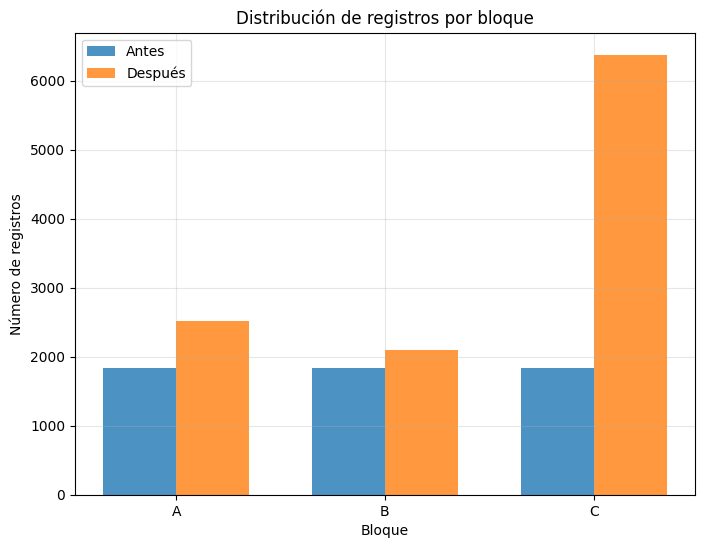

In [ ]:
# 1. Distribución de bloques antes vs después

dist_antes = datos_referencia['Warehouse_block'].value_counts().sort_index()
dist_despues = datos_integrados['Warehouse_block'].value_counts().sort_index()

x_pos = np.arange(len(bloques_referencia))
width = 0.35

plt.figure(figsize=(8, 6)) # Create a single figure
plt.bar(x_pos - width/2, dist_antes.values, width, label='Antes', alpha=0.8)
plt.bar(x_pos + width/2, dist_despues.values, width, label='Después', alpha=0.8)
plt.xlabel('Bloque')
plt.ylabel('Número de registros')
plt.title('Distribución de registros por bloque')
plt.xticks(x_pos, bloques_referencia)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # Display the plot

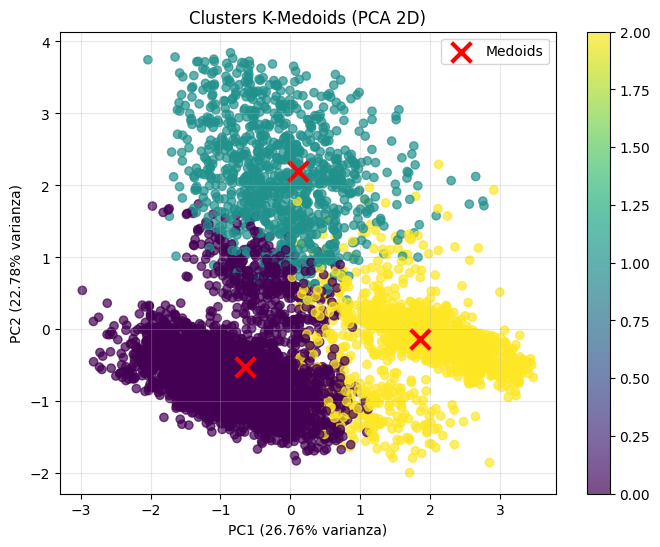

In [ ]:
# 2. Clustering visualization (usando PCA para 2D)
from sklearn.decomposition import PCA

# ax2 = axes[0, 1] # Remove this line as subplots are no longer used
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_referencia_scaled)

plt.figure(figsize=(8, 6)) # Create a new figure for this plot
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_referencia,
                     cmap='viridis', alpha=0.7)
plt.scatter(pca.transform(medoids)[:, 0], pca.transform(medoids)[:, 1],
           c='red', marker='x', s=200, linewidths=3, label='Medoids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
plt.title('Clusters K-Medoids (PCA 2D)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.colorbar(scatter) # Use plt.colorbar directly
plt.show() # Display the plot

14. Aquí, voy a poner un resumen de los resultados y luego pasaremos a realizar el análisis para comprender el ejercicio y sus respuestas

In [ ]:
print(f"""


Situación Inicial:
- 6 bloques físicos: A, B, C, D, E, F
- Total de registros: {len(df)}
- Registros en bloques de referencia (A,B,C): {len(datos_referencia)}
- Registros para integrar (D,E,F): {len(datos_integracion)}

Metodología Aplicada:
- Algoritmo: K-Medoids con k=3
- Variables utilizadas: {len(numerical_vars)} variables numéricas
- Métrica de distancia: Euclidiana
- Normalización: StandardScaler
- Calidad del clustering (Silhouette Score): {silhouette_avg:.4f}

Resultado Final:
- 3 bloques integrados: A, B, C
- Total de registros en dataset integrado: {len(datos_integrados)}
- Distribución final:
  * Bloque A: {distribucion_final['A']} registros
  * Bloque B: {distribucion_final['B']} registros
  * Bloque C: {distribucion_final['C']} registros

Criterio de Asignación:
- Cada registro de los bloques D,E,F fue asignado al bloque (A,B,C)
  cuyo medoide presentaba la menor distancia euclidiana
- La asignación garantiza máxima pertenencia a cada cluster


""")




Situación Inicial:
- 6 bloques físicos: A, B, C, D, E, F
- Total de registros: 10999
- Registros en bloques de referencia (A,B,C): 5499
- Registros para integrar (D,E,F): 5500

Metodología Aplicada:
- Algoritmo: K-Medoids con k=3
- Variables utilizadas: 6 variables numéricas
- Métrica de distancia: Euclidiana
- Normalización: StandardScaler
- Calidad del clustering (Silhouette Score): 0.2802

Resultado Final:
- 3 bloques integrados: A, B, C
- Total de registros en dataset integrado: 10999
- Distribución final:
  * Bloque A: 2524 registros
  * Bloque B: 2096 registros  
  * Bloque C: 6379 registros

Criterio de Asignación:
- Cada registro de los bloques D,E,F fue asignado al bloque (A,B,C) 
  cuyo medoide presentaba la menor distancia euclidiana
- La asignación garantiza máxima pertenencia a cada cluster





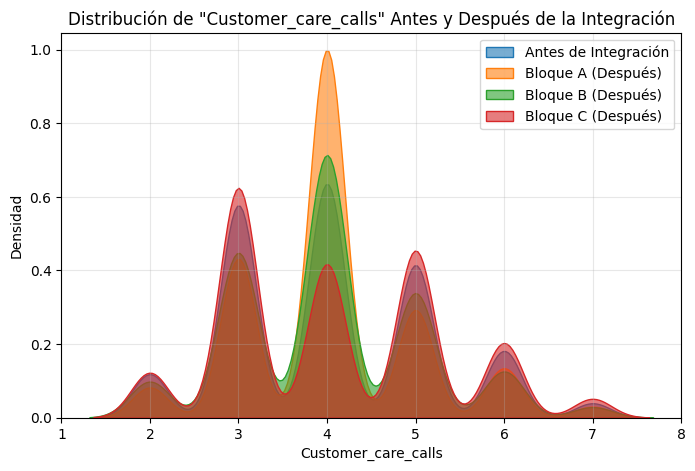

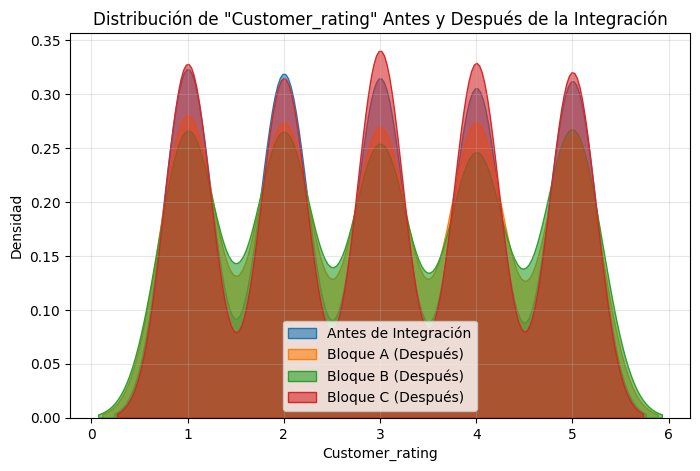

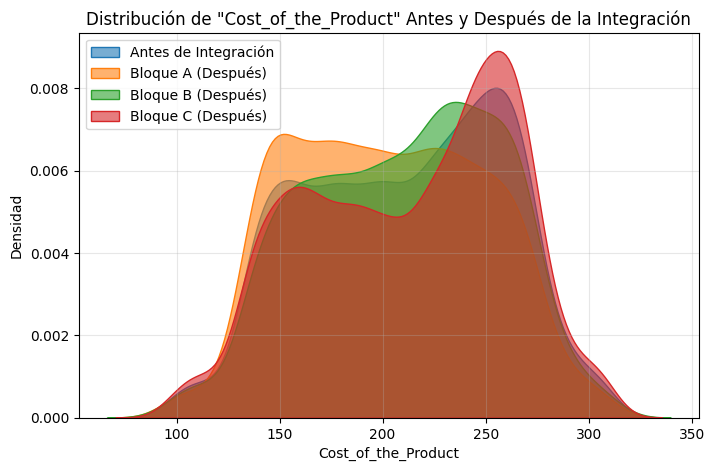

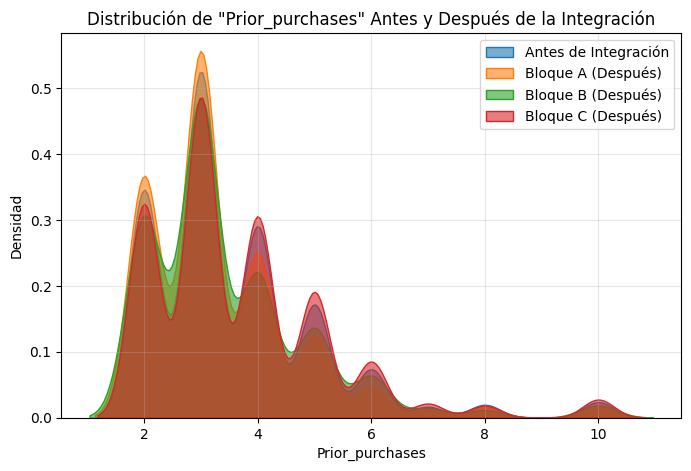

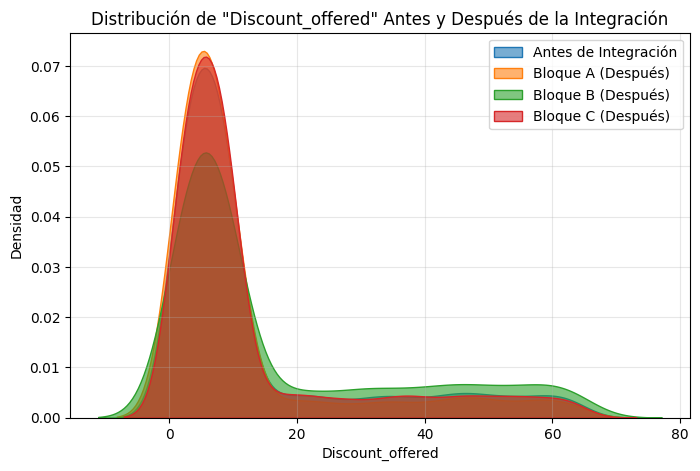

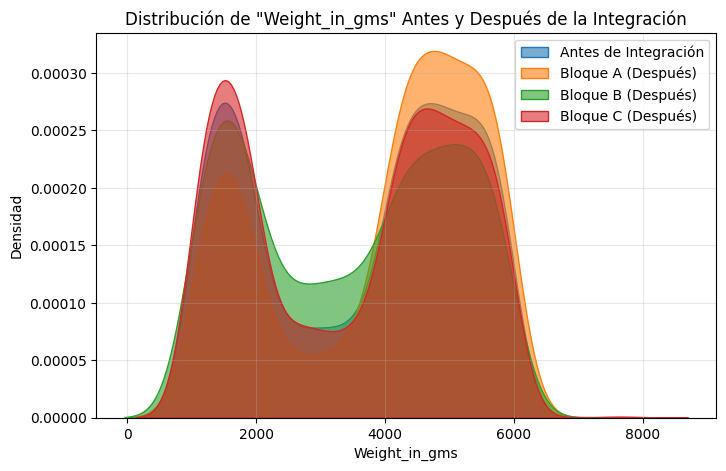

In [ ]:
# Grafico de distribución normal para ver como se comporta cada bloque y cada variable


for var in numerical_vars:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(datos_referencia[var], label='Antes de Integración', fill=True, alpha=0.6)
    sns.kdeplot(datos_integrados[datos_integrados['Warehouse_block'] == 'A'][var], label='Bloque A (Después)', fill=True, alpha=0.6)
    sns.kdeplot(datos_integrados[datos_integrados['Warehouse_block'] == 'B'][var], label='Bloque B (Después)', fill=True, alpha=0.6)
    sns.kdeplot(datos_integrados[datos_integrados['Warehouse_block'] == 'C'][var], label='Bloque C (Después)', fill=True, alpha=0.6)

    plt.title(f'Distribución de "{var}" Antes y Después de la Integración')
    plt.xlabel(var)
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



##**Análisis de resultados**



El análisis preliminar del dataset muestra que la base de datos cuenta con un total de 10.999 registros y 12 variables, dentro de las cuales se identifican tanto atributos numéricos como categóricos. La información se encuentra completa, sin presencia de valores nulos, lo que garantiza una buena calidad de los datos para su procesamiento posterior.

En cuanto a la distribución de los bloques físicos, se evidencia un equilibrio en la cantidad de registros para los bloques A, B, C y D, cada uno con aproximadamente 1833-1834 observaciones. Sin embargo, el bloque F concentra una cantidad significativamente mayor (3666 registros), lo que indica una posible concentración de operaciones en dicho bloque. Al parecer el bloque E, no tiene datos. Esta desproporción justifica la necesidad de realizar un proceso de integración y reorganización de la información, con el fin de optimizar la asignación hacia los nuevos bloques de referencia A, B y C.

&nbsp;


Al observar la caracterización inicial de los bloques A, B y C, se identifica una marcada homogeneidad en el comportamiento de las variables numéricas. En los tres bloques, el promedio de Customer_care_calls se mantiene alrededor de 4, con una desviación cercana a 1.1 y una ligera asimetría positiva, lo que indica que la mayoría de los clientes realizan entre 3 y 5 llamadas, aunque existen casos aislados con valores más altos. De forma similar, la variable Customer_rating presenta una media próxima a 3, con distribución ligeramente simétrica y curtosis negativa, lo que sugiere que la satisfacción de los clientes tiende a dispersarse en todo el rango de calificaciones sin concentrarse en valores extremos.

En lo relacionado con el Cost_of_the_Product, los tres bloques presentan valores promedio entre 208 y 212, con una dispersión en torno a 47 y una distribución relativamente simétrica. Esto evidencia que el costo de los productos es consistente entre bloques, sin grandes sesgos ni concentraciones. Por su parte, Prior_purchases exhibe un comportamiento más sesgado positivamente (asimetría > 1.6), lo que muestra que la mayoría de los clientes han realizado pocas compras previas, mientras que un pequeño grupo acumula un mayor número de adquisiciones. De manera similar, el Discount_offered presenta alta asimetría y curtosis positiva, reflejando que la mayoría de descuentos son bajos, pero existen casos puntuales de descuentos elevados. Finalmente, el Weight_in_gms muestra medias cercanas a 3600 gramos, con ligera asimetría negativa, lo que indica que predominan productos relativamente pesados, aunque también hay presencia de productos más livianos.

Respecto a las variables categóricas, los tres bloques mantienen una distribución prácticamente idéntica. El modo de envío predominante es Ship (alrededor del 68% de los registros), seguido en menor medida por Flight y Road, lo cual refleja una preferencia clara por el transporte marítimo. En cuanto a la Product_importance, prevalece el nivel low con valores cercanos al 48–50%, seguido de medium (41–45%) y finalmente high, que apenas representa alrededor del 9%. La variable Gender presenta una distribución equitativa entre hombres y mujeres, con diferencias mínimas entre bloques. Por último, el cumplimiento en la entrega (Reached.on.Time_Y.N) muestra que cerca del 59–60% de los pedidos llegaron a tiempo, mientras que alrededor del 40% presentó retrasos.

En conjunto, los resultados muestran que antes de la integración los bloques A, B y C poseen patrones estadísticos y distribuciones muy similares, tanto en variables numéricas como categóricas. Esta homogeneidad representa una base sólida para el proceso de integración y redistribución posterior, ya que facilita la consolidación de los bloques sin generar sesgos significativos entre ellos.


&nbsp;
&nbsp;


Los datos correspondientes a los bloques destinados a la integración suman un total de 5.500 registros, distribuidos entre los bloques D (1.834 registros) y F (3.666 registros). Se observa que el bloque F concentra más del 66% de la información de integración, lo que evidencia una carga operativa significativamente mayor en este bloque en comparación con D. Este desbalance sugiere que, en la reorganización hacia los bloques de referencia A, B y C, una parte sustancial de los registros provendrá del bloque F, generando un impacto más fuerte en las estadísticas de los bloques receptores.

En términos de calidad de los datos, tanto en los bloques de referencia (A, B y C) como en los de integración (D, E y F), no se presentan valores faltantes, lo que garantiza la consistencia y completitud de la información para el proceso de clusterización y reasignación mediante K-Medoids. Esto asegura que la redistribución de registros no se verá afectada por vacíos de información, permitiendo una integración más confiable.


&nbsp;
&nbsp;

Al aplicar el algoritmo K-Medoids con k=3, se obtuvo un Silhouette Score de 0.2802, lo que indica una cohesión y separación moderada entre los clusters. Aunque el valor no refleja una segmentación altamente definida, sí permite diferenciar grupos consistentes que servirán como base para la integración de los bloques.

En cuanto a la distribución de los registros de referencia (A, B y C) dentro de los clusters, se evidencia una estructura equilibrada: cada bloque aporta de manera proporcional a los tres grupos identificados. En promedio, cerca de 1.070 registros por bloque se concentran en el Cluster 0, alrededor de 320 en el Cluster 1 y aproximadamente 430 en el Cluster 2. Esto muestra que, si bien todos los bloques mantienen cierta diversidad interna, el Cluster 0 se constituye como el grupo más representativo para cada bloque, seguido por los Clusters 2 y 1 en menor proporción.

El análisis global muestra que, de los 5.499 registros de referencia, el 58.5% corresponde al Cluster 0 (3.220 registros), el 23.9% al Cluster 2 (1.314 registros) y el 17.5% al Cluster 1 (965 registros). Este resultado refleja una mayor concentración en un cluster dominante, lo cual facilita el proceso de reasignación de los bloques de integración (D, E, F) hacia los bloques de referencia A, B y C.


&nbsp;
&nbsp;
&nbsp;

El proceso de clústerización se basó en el método K-Medoids, el cual identificó tres puntos de referencia o "medoides" (XC) para los nuevos bloques A, B y C. Estos medoides, con una forma de (3, 6), representan el centro de cada futuro clúster, basándose en seis variables numéricas.

Los 5500 registros de los bloques D y F se procesaron para calcular su valor de pertenencia a cada uno de los tres medoides. La fórmula utilizada, VP=exp(−0.5∗media(((XC−XD
k
​
 )/XC)
2)), es una técnica de similitud que mide qué tan cerca está cada punto de datos de los medoides. La forma resultante de la matriz de pertenencia, (5500, 3), confirma que cada uno de los 5500 registros fue evaluado en relación con los tres bloques de referencia.

Las estadísticas de los valores de pertenencia revelan información clave sobre la calidad de la asignación.

Rango de pertenencia: Los valores de pertenencia varían desde un mínimo de 0.0 hasta un máximo de 0.988811, lo que indica que algunas asignaciones fueron casi perfectas (muy cercanas al valor máximo de 1.0), mientras que otras no mostraron ninguna afinidad con los bloques de referencia.

Media y desviación estándar: Con una media de 0.042370 y una desviación estándar de 0.151680, la mayoría de los valores de pertenencia son bajos. Esto sugiere que muchos de los datos de los bloques originales (D y F) no se parecían mucho a los medoides de los nuevos bloques (A, B y C). La alta desviación estándar confirma una gran variabilidad en la calidad de las asignaciones.



&nbsp;
&nbsp;

El proceso de integración ha reconfigurado la composición de los bloques, consolidando un total de 11,000 registros en tres nuevos grupos. La caracterización post-integración muestra que cada bloque tiene una identidad distinta, definida por las variables numéricas y categóricas. Este análisis es clave para entender cómo la reorganización afectará las operaciones logísticas y de inventario.

&nbsp;

Bloque A (2524 registros)

&nbsp;

Variables Cuantitativas

&nbsp;

El bloque A se caracteriza por un costo de producto más bajo en comparación con los otros bloques, con una media de 202.27. La mediana de 201 confirma que este valor es representativo. La desviación estándar es relativamente baja ($46.09), indicando que los precios de los productos en este bloque son bastante uniformes. Sin embargo, la variable Discount_offered presenta una asimetría muy alta (2.18) y una curtosis elevada (3.69), lo que sugiere una gran cantidad de productos con descuentos bajos y unos pocos con descuentos muy altos. La variable Prior_purchases también muestra una asimetría y curtosis altas, lo que indica que la mayoría de los clientes en este bloque tienen pocas compras previas, con algunos valores atípicos de muchas compras.

&nbsp;



Variables Cualitativas

&nbsp;

La mayoría de los envíos en el bloque A se realizan por Ship (67.0%), mientras que el transporte aéreo y por carretera se usan en menor medida. En cuanto a la Product_importance, casi la mitad de los productos son de "baja" importancia (49.2%), seguidos por los de "importancia media" (42.1%). La distribución de género de clientes es casi perfectamente equitativa (50.5% mujeres, 49.5% hombres). La tasa de entrega a tiempo (Reached.on.Time_Y.N) es del 55.4%, un poco más de la mitad de los envíos llegan en el tiempo estimado.


&nbsp;
&nbsp;

Bloque B (2096 registros)

&nbsp;

Variables Cuantitativas

&nbsp;

El bloque B presenta un costo de producto intermedio, con una media de 210.55. A diferencia del bloque A, la asimetría de esta variable es ligeramente negativa (-0.17), lo que sugiere la presencia de una pequeña cola de productos de menor costo. En cuanto a la variable Discount_offered, se observa una media significativamente más alta (16.96) en comparación con los otros bloques, acompañada de una desviación estándar considerable (18.70), lo que indica una gran variabilidad en los descuentos aplicados. La asimetría positiva (1.27) y la curtosis moderada (0.17) reflejan una distribución con algunos valores extremos, pero sin una concentración excesiva. Por otro lado, la variable Weight_in_gms muestra un sesgo negativo (-0.09) y una curtosis muy baja (-1.45), lo que podría indicar una distribución más plana y una tendencia hacia productos más pesados en promedio respecto a los otros bloques.


&nbsp;

Variables Cualitativas

&nbsp;

Al igual que en el bloque A, la mayoría de los envíos en el bloque B se realizan por Ship (67.4%). La distribución de la importancia de los productos es similar a la del bloque A. Una diferencia notable es la alta tasa de entrega a tiempo (Reached.on.Time_Y.N), que alcanza el 65.2%. Esto podría indicar que las rutas y la logística asociadas a este bloque son más eficientes. La distribución de género es equitativa, con una ligera mayoría de hombres (50.9%).

&nbsp;

Bloque C (6379 registros)

&nbsp;

Variables Cuantitativas

&nbsp;

El bloque C es el más grande de los tres, con más de 6,000 registros, y se caracteriza por tener el costo de producto más alto (213.22) de los tres bloques. La desviación estándar (49.20) es la más alta, lo que indica una mayor dispersión en los precios de los productos. La variable Prior_purchases tiene los valores más altos de asimetría y curtosis entre los tres bloques, lo que confirma una fuerte concentración de clientes con pocas compras previas. La variable Weight_in_gms tiene una media similar a la de los otros bloques, pero la desviación estándar es la más alta (1653.69), lo que indica una mayor variedad de pesos de los productos.

&nbsp;

Variables Cualitativas

&nbsp;

Este bloque también utiliza principalmente el transporte por Ship (68.3%). La distribución de la importancia de los productos es muy similar a la de los otros dos bloques. La distribución de género es equitativa. La tasa de entrega a tiempo (Reached.on.Time_Y.N) es del 59.5%, un punto intermedio entre los bloques A y B.






